<a href="https://colab.research.google.com/github/cu24250113-priyashi/Computer_Vision/blob/main/Labsheet3(CV).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [43]:
import cv2
from google.colab.patches import cv2_imshow
import matplotlib.pyplot as plt
import numpy as np
import ipywidgets as widgets
from IPython.display import display, clear_output

Original Image:


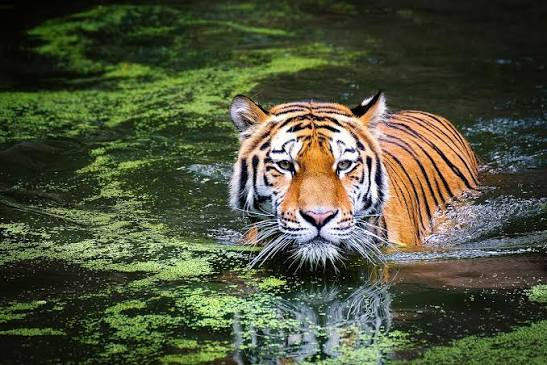

In [44]:
image_path = "/content/tiger.jpeg"
img = cv2.imread(image_path, -1)
print('Original Image:')
cv2_imshow(img)

Build a noise-removeal tool using Gaussian,Median and Mode filters, and compare thier effectiveness on Salt-and-Pepper Noise.


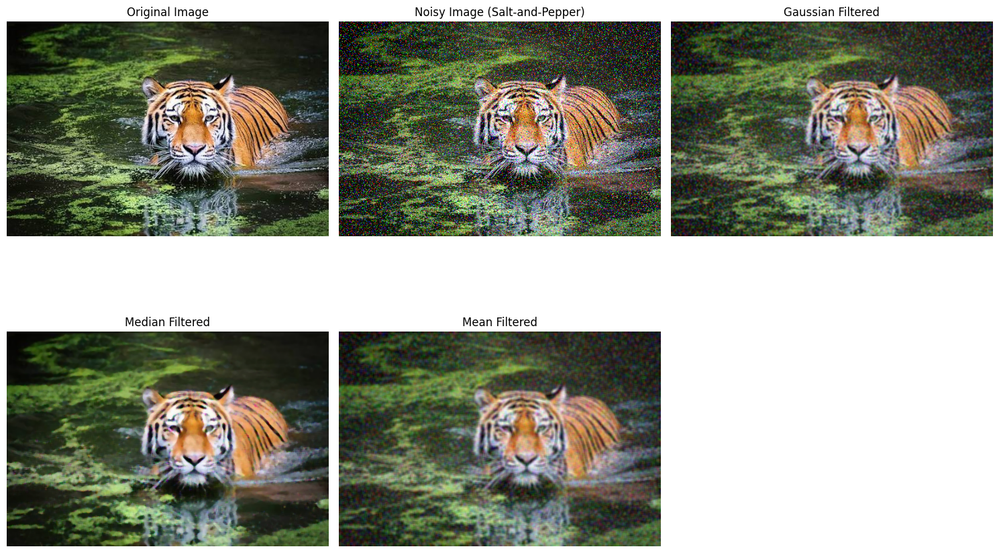

In [45]:
def add_salt_and_pepper_noise(image, prob=0.05):
    noisy_image = np.copy(image)
    total_pixels = image.size
    if len(image.shape) == 2:
        num_salt = np.ceil(prob * total_pixels * 0.5)
        coords = [np.random.randint(0, i - 1, int(num_salt)) for i in image.shape]
        noisy_image[coords[0], coords[1]] = 255
        num_pepper = np.ceil(prob * total_pixels * 0.5)
        coords = [np.random.randint(0, i - 1, int(num_pepper)) for i in image.shape]
        noisy_image[coords[0], coords[1]] = 0
    elif len(image.shape) == 3:
        for i in range(image.shape[2]):
            num_salt = np.ceil(prob * total_pixels * 0.5)
            coords = [np.random.randint(0, j - 1, int(num_salt)) for j in image.shape[:2]]
            noisy_image[coords[0], coords[1], i] = 255
            num_pepper = np.ceil(prob * total_pixels * 0.5)
            coords = [np.random.randint(0, j - 1, int(num_pepper)) for j in image.shape[:2]]
            noisy_image[coords[0], coords[1], i] = 0
    return noisy_image
noisy_image = add_salt_and_pepper_noise(img, prob=0.05)
gaus_filtered_image = cv2.GaussianBlur(noisy_image, (5, 5), 0)
median_filtered_image = cv2.medianBlur(noisy_image, 5)
mean_filtered_image = cv2.blur(noisy_image, (5, 5))
plt.figure(figsize=(15, 10))
plt.subplot(2, 3, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Original Image')
plt.axis('off')
plt.subplot(2, 3, 2)
plt.imshow(cv2.cvtColor(noisy_image, cv2.COLOR_BGR2RGB))
plt.title('Noisy Image (Salt-and-Pepper)')
plt.axis('off')
plt.subplot(2, 3, 3)
plt.imshow(cv2.cvtColor(gaus_filtered_image, cv2.COLOR_BGR2RGB))
plt.title('Gaussian Filtered')
plt.axis('off')
plt.subplot(2, 3, 4)
plt.imshow(cv2.cvtColor(median_filtered_image, cv2.COLOR_BGR2RGB))
plt.title('Median Filtered')
plt.axis('off')
plt.subplot(2, 3, 5)
plt.imshow(cv2.cvtColor(mean_filtered_image, cv2.COLOR_BGR2RGB))
plt.title('Mean Filtered')
plt.axis('off')
plt.tight_layout()
plt.show()

Develop an edge-detection demo using high pass filters(Laplacian and sobal kernals) and visualize the resulting edge maps.


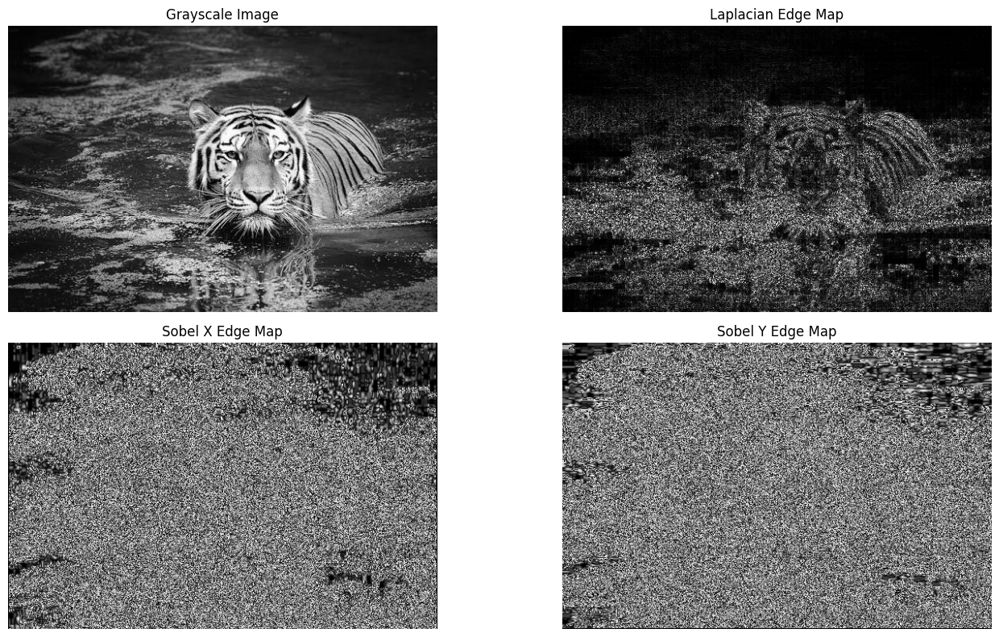

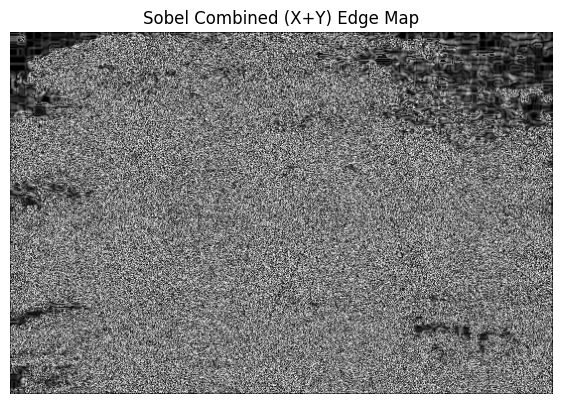

In [47]:
grayscale_image = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
laplacian = cv2.Laplacian(grayscale_image, cv2.CV_64F)
laplacian_abs = np.uint8(np.absolute(laplacian))
sobelx = cv2.Sobel(grayscale_image, cv2.CV_64F, 1, 0, ksize=5)
sobelx_abs = np.uint8(np.absolute(sobelx))
sobely = cv2.Sobel(grayscale_image, cv2.CV_64F, 0, 1, ksize=5)
sobely_abs = np.uint8(np.absolute(sobely))
sobel_combined = cv2.addWeighted(sobelx_abs, 0.5, sobely_abs, 0.5, 0)
plt.figure(figsize=(15, 8))
plt.subplot(2, 2, 1)
plt.imshow(grayscale_image, cmap='gray')
plt.title('Grayscale Image')
plt.axis('off')
plt.subplot(2, 2, 2)
plt.imshow(laplacian_abs, cmap='gray')
plt.title('Laplacian Edge Map')
plt.axis('off')
plt.subplot(2, 2, 3)
plt.imshow(sobelx_abs, cmap='gray')
plt.title('Sobel X Edge Map')
plt.axis('off')
plt.subplot(2, 2, 4)
plt.imshow(sobely_abs, cmap='gray')
plt.title('Sobel Y Edge Map')
plt.axis('off')
plt.tight_layout()
plt.show()
plt.figure(figsize=(7, 7))
plt.imshow(sobel_combined, cmap='gray')
plt.title('Sobel Combined (X+Y) Edge Map')
plt.axis('off')
plt.show()

Create an interactive blur tool with adjustable kernal size for real-time low-pass filtering.



In [48]:
def apply_gaussian_blur(kernel_size):
    kernel_size = int(kernel_size)
    if kernel_size % 2 == 0:
        kernel_size += 1
    if kernel_size < 1:
        kernel_size = 1
    blurred_image = cv2.GaussianBlur(img, (kernel_size, kernel_size), 0)
    display_image = cv2.cvtColor(blurred_image, cv2.COLOR_BGR2RGB)
    with output_widget:
        clear_output(wait=True)
        plt.figure(figsize=(8, 8))
        plt.imshow(display_image)
        plt.title(f'Gaussian Blurred Image (Kernel Size: {kernel_size}x{kernel_size})')
        plt.axis('off')
        plt.show()
kernel_size_slider = widgets.IntSlider(
    value=5,
    min=1,
    max=31,
    step=2,
    description='Kernel Size:',
    continuous_update=True,
    orientation='horizontal',
    readout=True,
    readout_format='d'
)
output_widget = widgets.Output()
widgets.interact(apply_gaussian_blur, kernel_size=kernel_size_slider);
display(output_widget)

interactive(children=(IntSlider(value=5, description='Kernel Size:', max=31, min=1, step=2), Output()), _dom_c…

Output()


Build a sharpening tool that applies unsharp masking to enhance fine details in an image.

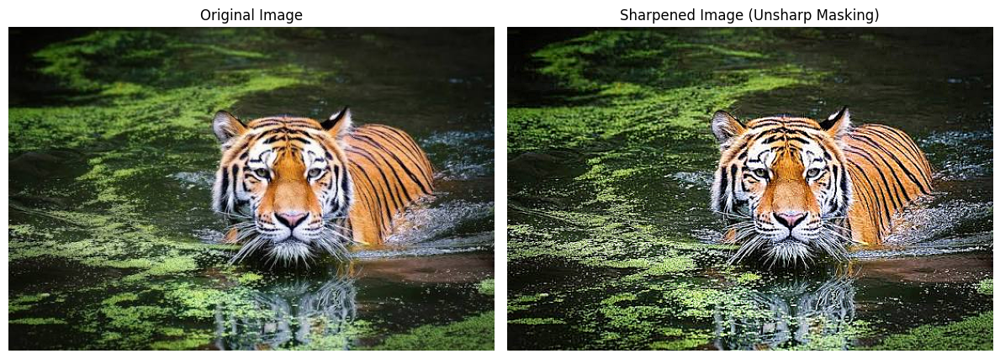

In [49]:
def unsharp_masking(image, blur_kernel_size=(5, 5), amount=1.5):
    blurred = cv2.GaussianBlur(image, blur_kernel_size, 0)
    image_float = image.astype(np.float32)
    blurred_float = blurred.astype(np.float32)
    sharpened = image_float + (image_float - blurred_float) * amount
    sharpened = np.clip(sharpened, 0, 255).astype(np.uint8)
    return sharpened
sharpened_image = unsharp_masking(img, blur_kernel_size=(5, 5), amount=1.5)
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Original Image')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(sharpened_image, cv2.COLOR_BGR2RGB))
plt.title('Sharpened Image (Unsharp Masking)')
plt.axis('off')
plt.tight_layout()
plt.show()


Develope a custome convolution kernel designer where user input thier own kernel matrix and apply it on an image

In [52]:
def apply_custom_kernel(image, kernel_matrix_str, kernel_width, kernel_height):
    try:
        kernel_values = [float(x) for x in kernel_matrix_str.replace(',', ' ').split()]

        kernel = np.array(kernel_values).reshape(kernel_height, kernel_width)
    except ValueError:
        print("Error: Invalid kernel matrix format. Please enter numbers separated by spaces or commas.")
        return None
    except Exception as e:
        print(f"Error creating kernel: {e}. Make sure the number of elements matches width * height.")
        return None
    filtered_image = cv2.filter2D(image.astype(np.float32), -1, kernel)
    filtered_image = np.clip(filtered_image, 0, 255).astype(np.uint8)
    return filtered_image
kernel_input_widget = widgets.Textarea(
    value='0, -1, 0, -1, 5, -1, 0, -1, 0',
    description='Kernel Matrix:',
    continuous_update=False,
    layout=widgets.Layout(width='auto', height='100px'))
kernel_width_widget = widgets.IntText(
    value=3,
    description='Width:',
    min=1,
    max=15 )
kernel_height_widget = widgets.IntText(
    value=3,
    description='Height:',
    min=1,
    max=15 )
apply_button = widgets.Button(
    description='Apply Custom Kernel',
    button_style='success',
    tooltip='Click to apply the custom kernel to the image')
output_display = widgets.Output()
def on_apply_button_clicked(_):
    with output_display:
        clear_output(wait=True)
        kernel_matrix_str = kernel_input_widget.value
        kernel_width = kernel_width_widget.value
        kernel_height = kernel_height_widget.value
        if kernel_width * kernel_height == len(kernel_matrix_str.replace(',', ' ').split()):
            result_image = apply_custom_kernel(img, kernel_matrix_str, kernel_width, kernel_height)
            if result_image is not None:
                plt.figure(figsize=(15, 7))
                plt.subplot(1, 2, 1)
                plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
                plt.title('Original Image')
                plt.axis('off')
                plt.subplot(1, 2, 2)
                plt.imshow(cv2.cvtColor(result_image, cv2.COLOR_BGR2RGB))
                plt.title('Filtered Image with Custom Kernel')
                plt.axis('off')
                plt.tight_layout()
                plt.show()
        else:
            print(f"Error: Number of elements in kernel string ({len(kernel_matrix_str.replace(',', ' ').split())}) does not match width ({kernel_width}) * height ({kernel_height}).")
apply_button.on_click(on_apply_button_clicked)
input_widgets = widgets.VBox([
    widgets.HBox([kernel_width_widget, kernel_height_widget]),
    kernel_input_widget,
    apply_button
])
display(input_widgets, output_display)



Output()

Create a bilateral filtering demo that smooths an image while perserving edges and compare it with standard gaussian blur.

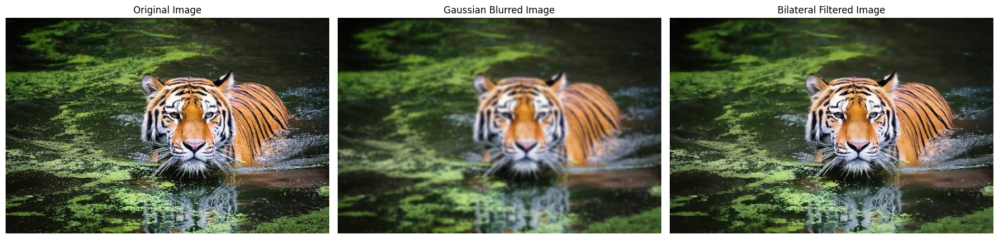

In [ ]:
gaus_blurred_img = cv2.GaussianBlur(img, (9, 9), 0)
bilateral_filtered_img = cv2.bilateralFilter(img, d=9, sigmaColor=75, sigmaSpace=75)
plt.figure(figsize=(18, 6))
plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Original Image')
plt.axis('off')
plt.subplot(1, 3, 2)
plt.imshow(cv2.cvtColor(gaus_blurred_img, cv2.COLOR_BGR2RGB))
plt.title('Gaussian Blurred Image')
plt.axis('off')
plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(bilateral_filtered_img, cv2.COLOR_BGR2RGB))
plt.title('Bilateral Filtered Image')
plt.axis('off')
plt.tight_layout()
plt.show()

Build a denoising pipeline for old or scanned photographs using a combination of spatial filters.

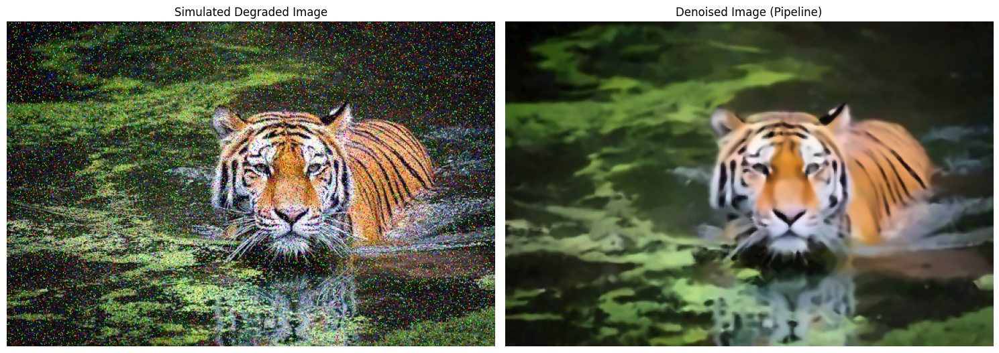

In [53]:
def add_gaussian_noise(image, mean=0, var=0.01):
    image = np.array(image/255, dtype=np.float32)
    sigma = var**0.5
    gaussian = np.random.normal(mean, sigma, image.shape).astype(np.float32)
    noisy_image = image + gaussian
    noisy_image = np.clip(noisy_image, 0, 1)
    noisy_image = np.array(noisy_image * 255, dtype=np.uint8)
    return noisy_image
degraded_image = add_salt_and_pepper_noise(img, prob=0.03)
degraded_image = add_gaussian_noise(degraded_image, mean=0, var=0.005)
def denoise_photo_pipeline(image):
    median_denoised = cv2.medianBlur(image, 5)
    denoised_image = cv2.fastNlMeansDenoisingColored(
        median_denoised, None, h=10, hColor=10, templateWindowSize=7, searchWindowSize=21
    )
    return denoised_image
restored_image = denoise_photo_pipeline(degraded_image)
plt.figure(figsize=(15, 7))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(degraded_image, cv2.COLOR_BGR2RGB))
plt.title('Simulated Degraded Image')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(restored_image, cv2.COLOR_BGR2RGB))
plt.title('Denoised Image (Pipeline)')
plt.axis('off')
plt.tight_layout()
plt.show()


Develop a program that reduces simple motion-blur artifacts using high-pass sharpening techniques.

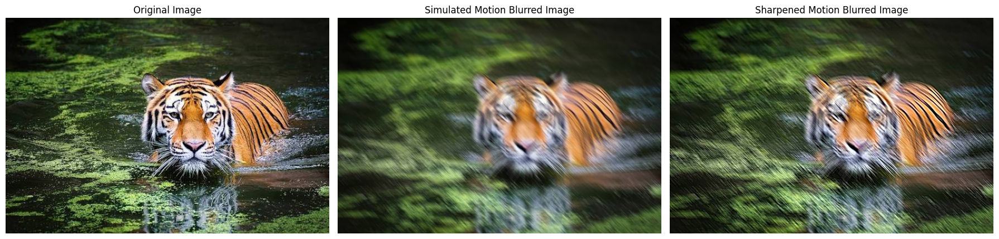

In [54]:
def create_motion_blur_kernel(size, angle):
    kernel = np.zeros((size, size), dtype=np.float32)
    center = size // 2
    angle_rad = np.deg2rad(angle)
    for i in range(size):
        x = int(center + (i - center) * np.cos(angle_rad))
        y = int(center + (i - center) * np.sin(angle_rad))
        if 0 <= x < size and 0 <= y < size:
            kernel[y, x] = 1
    kernel = kernel / np.sum(kernel)
    return kernel
motion_blur_kernel = create_motion_blur_kernel(15, 45)
motion_blurred_image = cv2.filter2D(img, -1, motion_blur_kernel)
sharpened_motion_blurred = unsharp_masking(motion_blurred_image, blur_kernel_size=(7, 7), amount=2.0)
plt.figure(figsize=(18, 6))
plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Original Image')
plt.axis('off')
plt.subplot(1, 3, 2)
plt.imshow(cv2.cvtColor(motion_blurred_image, cv2.COLOR_BGR2RGB))
plt.title('Simulated Motion Blurred Image')
plt.axis('off')
plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(sharpened_motion_blurred, cv2.COLOR_BGR2RGB))
plt.title('Sharpened Motion Blurred Image')
plt.axis('off')
plt.tight_layout()
plt.show()

Create a "cartoonify" effect generater using edge detection combined with smoothing filters.

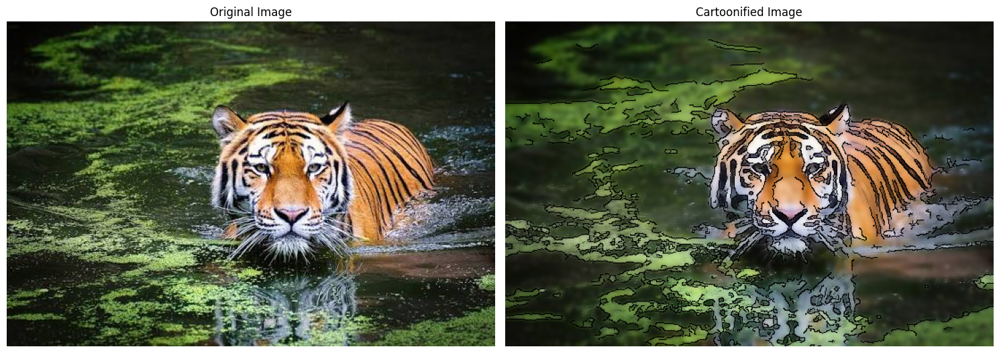

In [55]:
gray_cartoon = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blur_gray = cv2.medianBlur(gray_cartoon, 5)
edges = cv2.Canny(blur_gray, threshold1=100, threshold2=200)
edges_colored = cv2.cvtColor(edges, cv2.COLOR_GRAY2BGR)
smoothed_colors = cv2.bilateralFilter(img, d=9, sigmaColor=200, sigmaSpace=200)
cartoon_image = cv2.bitwise_and(smoothed_colors, smoothed_colors, mask=~edges)
plt.figure(figsize=(15, 7))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Original Image')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(cartoon_image, cv2.COLOR_BGR2RGB))
plt.title('Cartoonified Image')
plt.axis('off')
plt.tight_layout()
plt.show()

Buid a comparison dashboard that reports PSNR/SSIM scores for different filtering techniques to the same noisy image

In [56]:
from skimage.metrics import peak_signal_noise_ratio, structural_similarity
import pandas as pd
results = []
def calculate_metrics(filtered_img, filter_name):
    if filtered_img.shape != img.shape:
        if len(filtered_img.shape) == 2 and len(img.shape) == 3:
            filtered_img_bgr = cv2.cvtColor(filtered_img, cv2.COLOR_GRAY2BGR)
        elif len(filtered_img.shape) == 3 and len(img.shape) == 2:
            img_bgr = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
            pass
        else:
            filtered_img_bgr = filtered_img
    else:
        filtered_img_bgr = filtered_img
    min_dim_spatial = min(img.shape[0], img.shape[1])
    ssim_win_size = min(7, min_dim_spatial)
    if ssim_win_size % 2 == 0:
        ssim_win_size -= 1
    if ssim_win_size < 1:
        ssim_win_size = 1
    psnr = peak_signal_noise_ratio(img, filtered_img_bgr)
    ssim = structural_similarity(img, filtered_img_bgr, channel_axis=-1, data_range=filtered_img_bgr.max() - filtered_img_bgr.min(), win_size=ssim_win_size)
    results.append({'Filter': filter_name, 'PSNR': psnr, 'SSIM': ssim})
calculate_metrics(noisy_image, 'Noisy Image (Salt-and-Pepper)')
calculate_metrics(gaus_filtered_image, 'Gaussian Filter')
calculate_metrics(median_filtered_image, 'Median Filter')
calculate_metrics(mean_filtered_image, 'Mean Filter')
if 'restored_image' in locals():
    calculate_metrics(restored_image, 'Denoising Pipeline (Median + NLM)')
comparison_df = pd.DataFrame(results)
display(comparison_df.set_index('Filter'))

,PSNR,SSIM
Filter,,
Noisy Image (Salt-and-Pepper),13.234616,0.319853
Gaussian Filter,19.408532,0.478801
Median Filter,20.150132,0.600733
Mean Filter,18.667002,0.395035
Denoising Pipeline (Median + NLM),19.844224,0.512594
